# 07 — Ensemble Learning: Bagging, Random Forest, Boosting

Telco Customer Churn — Decision Trees & Ensemble Learning project

## 1. Learning Objectives

- Explain why a single decision tree can be unstable
- Understand bagging (bootstrap aggregating) and how it reduces variance
- Explain how a Random Forest adds random feature selection on top of bagging
- Understand boosting conceptually and how it differs fundamentally from bagging
- Train and compare Decision Tree, Random Forest, and Gradient Boosting
- Build the final model comparison table and reason about model selection
- Perform final error analysis across all models

## 2. Business Problem

We have a tuned single decision tree (notebook 06). Can we do better by
combining multiple trees? This notebook builds two different families of
"many trees" models — bagging (Random Forest) and boosting (Gradient
Boosting) — and compares all our models honestly, including their
trade-offs, not just their scores.

## 3. Concept Explanation — Why a Single Tree is Unstable

```
One Decision Tree
        |
Potentially unstable
        |
Small change to training data
        |
Can produce a very different tree
```

Decision trees are "greedy": at each node they pick whichever split looks
best on the data reaching that node. A small change in the training data
(a few different rows) can change which feature looks best at the ROOT,
which cascades into a completely different tree below it. This sensitivity
to small data changes is called **high variance**.

**Ensemble learning's core idea:** if individual models are unstable but
their errors aren't all identical, *combining* their predictions can cancel
out a lot of that instability.

## 4. Concept Explanation — Bagging (Bootstrap Aggregating)

```
Bootstrap Dataset 1 -> Tree 1
Bootstrap Dataset 2 -> Tree 2
Bootstrap Dataset 3 -> Tree 3
Bootstrap Dataset 4 -> Tree 4
                    |
              Combine Results (majority vote / average)
```

### What is bootstrapping?
Randomly sampling rows from the training set **with replacement**, to
create a new dataset the same size as the original. Some original rows
appear multiple times; others don't appear at all (~37% are typically left
out of any given bootstrap sample — these are called "out-of-bag" samples).

### Why does bagging reduce variance?
Each tree sees a slightly different bootstrap dataset, so each tree makes
somewhat different mistakes. Averaging (for probabilities) or majority-
voting (for class labels) across many such trees smooths out any single
tree's idiosyncratic errors, without needing any single tree to be
individually accurate.

## 5. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing.preprocessor import split_dataset, encode_categorical_features
from src.models.decision_tree_model import DecisionTreeModel
from src.models.random_forest_model import RandomForestModel
from src.models.gradient_boosting_model import GradientBoostingModel
from src.evaluation.model_evaluator import evaluate_predictions
from sklearn.dummy import DummyClassifier

pd.set_option("display.max_columns", None)

## 6. Load Data

In [2]:
processed_data = pd.read_csv("../data/processed/processed_data.csv")
feature_columns = processed_data.drop(columns=["customerID", "Churn"]).columns
features = processed_data[feature_columns]
target = processed_data["Churn"]

training_features, testing_features, training_target, testing_target = split_dataset(features, target)
training_encoded, testing_encoded = encode_categorical_features(training_features, testing_features)

2026-09-16 00:13:27 | INFO | src.preprocessing.preprocessor | Split dataset: 5634 training rows, 1409 testing rows (test_size=0.2)


2026-09-16 00:13:27 | INFO | src.preprocessing.preprocessor | One-hot encoding 15 categorical column(s)


## 7. Demonstrating Tree Instability

Before building the forest, let's actually SEE the instability bagging is
meant to fix: train the same tree architecture on 3 different bootstrap
samples of the training data and compare which feature each one picks at
the root.

In [3]:
rng = np.random.RandomState(42)

for trial in range(3):
    bootstrap_indices = rng.choice(len(training_encoded), size=len(training_encoded), replace=True)
    bootstrap_features = training_encoded.iloc[bootstrap_indices]
    bootstrap_target = training_target.iloc[bootstrap_indices]

    trial_tree = DecisionTreeModel(criterion="gini", max_depth=3, random_state=trial)
    trial_tree.fit(bootstrap_features, bootstrap_target)

    root_feature_index = trial_tree.classifier.tree_.feature[0]
    root_feature_name = training_encoded.columns[root_feature_index]
    print(f"Trial {trial+1}: root split feature = '{root_feature_name}'")

2026-09-16 00:13:27 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=3, min_samples_split=2, min_samples_leaf=1)


2026-09-16 00:13:27 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:27 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=3, min_samples_split=2, min_samples_leaf=1)


2026-09-16 00:13:27 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:27 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=3, min_samples_split=2, min_samples_leaf=1)


2026-09-16 00:13:27 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


Trial 1: root split feature = 'Contract_Month-to-month'
Trial 2: root split feature = 'Contract_Month-to-month'
Trial 3: root split feature = 'Contract_Month-to-month'


**Interpretation:** if the root feature changes across trials, that's
direct evidence of the instability described in section 3 — small data
changes (here, which rows got resampled) changed the tree's very first
decision. (If all 3 happen to agree, that just means this particular
feature's signal is strong enough to dominate regardless of resampling —
still worth noting, since not every dataset behaves this way.)

## 8. Random Forest

A Random Forest is bagging **plus one more trick**: at each split, only a
random SUBSET of features is considered (not all of them). This
deliberately prevents every tree from all leaning on the single strongest
feature, which would make the bagged trees too similar to each other (and
therefore less effective at canceling out each other's errors).

| | Bagging | Random Forest |
|---|---|---|
| Bootstrap sampling of rows | Yes | Yes |
| Random subset of features per split | No | Yes |
| Reduces variance | Yes | Yes, more effectively |

In [4]:
random_forest = RandomForestModel(n_estimators=100, max_depth=10)
random_forest.fit(training_encoded, training_target)
forest_metrics = random_forest.evaluate(testing_encoded, testing_target)
print(forest_metrics.to_dict())

2026-09-16 00:13:27 | INFO | src.models.random_forest_model | Initialized RandomForestModel(n_estimators=100, max_depth=10)


2026-09-16 00:13:28 | INFO | src.models.random_forest_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:28 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.650 recall=0.521 f1=0.579 roc_auc=0.839


{'accuracy': 0.7984386089425124, 'precision': 0.65, 'recall': 0.5213903743315508, 'f1': 0.5786350148367952, 'roc_auc': 0.8385168823787751}


### Decision Tree vs. Random Forest

In [5]:
single_tree = DecisionTreeModel(criterion="gini", max_depth=5)
single_tree.fit(training_encoded, training_target)
tree_metrics = single_tree.evaluate(testing_encoded, testing_target)

tree_vs_forest = pd.DataFrame({
    "decision_tree": tree_metrics.to_dict(),
    "random_forest": forest_metrics.to_dict(),
})
tree_vs_forest

2026-09-16 00:13:28 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=5, min_samples_split=2, min_samples_leaf=1)


2026-09-16 00:13:28 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:28 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.635 recall=0.567 f1=0.599 roc_auc=0.830


,decision_tree,random_forest
accuracy,0.798439,0.798439
precision,0.634731,0.650000
recall,0.566845,0.521390
f1,0.598870,0.578635
roc_auc,0.830100,0.838517


**Interpretation:** look especially at ROC-AUC — Random Forest usually
improves ranking quality noticeably over a single tree, even when raw
accuracy is similar, because averaging many trees' probability estimates
produces smoother, more reliable probabilities than one tree's abrupt
leaf-based predictions.

## 9. Boosting — Conceptual Explanation

```
Model 1  (weak learner, makes some mistakes)
   |
Find mistakes (residual errors)
   |
Model 2 focuses MORE on the mistakes Model 1 made
   |
Model 3 focuses on whatever mistakes remain
   |
Final ensemble = weighted sum of all models
```

### Bagging vs. Boosting — the fundamental difference

> **Bagging trains models mostly independently (in parallel, on different
> bootstrap samples) and combines them by voting/averaging. Boosting builds
> models sequentially, where each new model is trained specifically to
> correct the errors of the ensemble so far.**

Because boosting trees are trained sequentially to fix specific mistakes,
each one is typically shallow (a "weak learner") — the ensemble's power
comes from the sequence of corrections, not from any individual tree being
powerful on its own.

## 10. Gradient Boosting in Practice

In [6]:
gradient_boosting = GradientBoostingModel(n_estimators=100, learning_rate=0.1, max_depth=3)
gradient_boosting.fit(training_encoded, training_target)
boosting_metrics = gradient_boosting.evaluate(testing_encoded, testing_target)
print(boosting_metrics.to_dict())

2026-09-16 00:13:28 | INFO | src.models.gradient_boosting_model | Initialized GradientBoostingModel(n_estimators=100, learning_rate=0.1, max_depth=3)


2026-09-16 00:13:32 | INFO | src.models.gradient_boosting_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:32 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.803 precision=0.668 recall=0.516 f1=0.582 roc_auc=0.842


{'accuracy': 0.8034066713981547, 'precision': 0.6678200692041523, 'recall': 0.516042780748663, 'f1': 0.5822021116138764, 'roc_auc': 0.8424552429667519}


### Experiment: what does `learning_rate` actually control?

Lower `learning_rate` values shrink each tree's contribution, usually
needing more `n_estimators` to reach similar performance — but often
generalizing better because no single stage can dominate the ensemble.

In [7]:
learning_rate_results = []
for rate in [0.01, 0.1, 0.3, 1.0]:
    trial_model = GradientBoostingModel(n_estimators=100, learning_rate=rate, max_depth=3)
    trial_model.fit(training_encoded, training_target)
    trial_metrics = trial_model.evaluate(testing_encoded, testing_target)
    learning_rate_results.append({"learning_rate": rate, **trial_metrics.to_dict()})

pd.DataFrame(learning_rate_results)

2026-09-16 00:13:32 | INFO | src.models.gradient_boosting_model | Initialized GradientBoostingModel(n_estimators=100, learning_rate=0.01, max_depth=3)


2026-09-16 00:13:35 | INFO | src.models.gradient_boosting_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:35 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.779 precision=0.701 recall=0.294 f1=0.414 roc_auc=0.840


2026-09-16 00:13:35 | INFO | src.models.gradient_boosting_model | Initialized GradientBoostingModel(n_estimators=100, learning_rate=0.1, max_depth=3)


2026-09-16 00:13:38 | INFO | src.models.gradient_boosting_model | Model trained on 5634 samples, 47 features


...

2026-09-16 00:13:41 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.791 precision=0.628 recall=0.524 f1=0.571 roc_auc=0.821


2026-09-16 00:13:41 | INFO | src.models.gradient_boosting_model | Initialized GradientBoostingModel(n_estimators=100, learning_rate=1.0, max_depth=3)


2026-09-16 00:13:44 | INFO | src.models.gradient_boosting_model | Model trained on 5634 samples, 47 features


2026-09-16 00:13:44 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.754 precision=0.540 recall=0.492 f1=0.515 roc_auc=0.780


,learning_rate,accuracy,precision,recall,f1,roc_auc
0,0.01,0.779276,0.700637,0.294118,0.414313,0.839504
1,0.10,0.803407,0.667820,0.516043,0.582202,0.842455
2,0.30,0.791341,0.628205,0.524064,0.571429,0.820655
3,1.00,0.753726,0.539589,0.491979,0.514685,0.780337


**Interpretation:** a very high learning rate (1.0) lets early trees
overcorrect, which can hurt generalization; a very low rate (0.01) may
underfit within only 100 estimators, since each tree contributes too
little. `0.1` is scikit-learn's default for good reason — it's usually a
reasonable middle ground.

## 11. Final Model Comparison

We now compute every model honestly on the SAME held-out test set,
including the baseline from notebook 05 for context.

In [8]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(training_encoded, training_target)
baseline_metrics = evaluate_predictions(testing_target, baseline.predict(testing_encoded))

final_comparison = pd.DataFrame({
    "Baseline": baseline_metrics.to_dict(),
    "Decision Tree": tree_metrics.to_dict(),
    "Random Forest": forest_metrics.to_dict(),
    "Gradient Boosting": boosting_metrics.to_dict(),
}).T

final_comparison.round(3)

2026-09-16 00:13:44 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.735 precision=0.000 recall=0.000 f1=0.000 roc_auc=nan


,accuracy,precision,recall,f1,roc_auc
Baseline,0.735,0.000,0.000,0.000,NaN
Decision Tree,0.798,0.635,0.567,0.599,0.830
Random Forest,0.798,0.650,0.521,0.579,0.839
Gradient Boosting,0.803,0.668,0.516,0.582,0.842


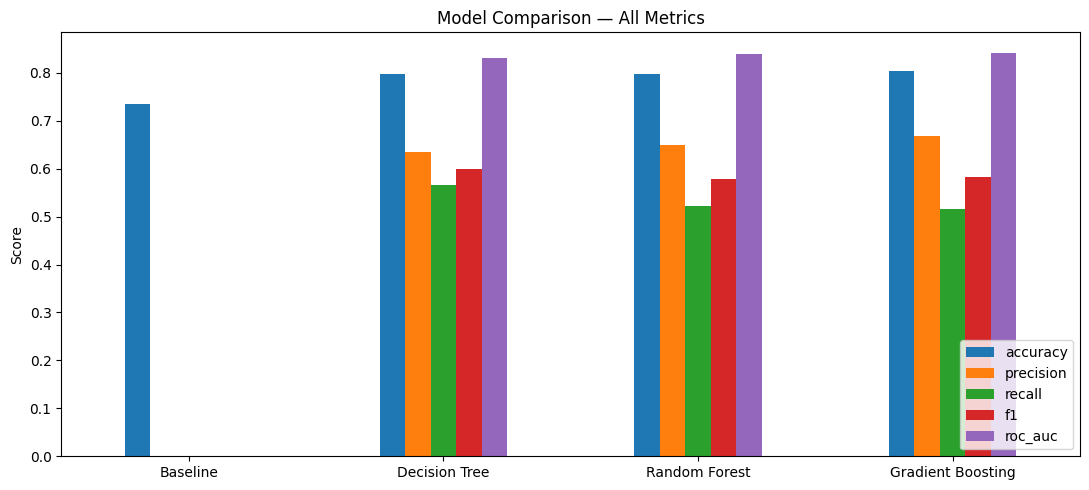

In [9]:
final_comparison[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(11, 5), rot=0
)
plt.title("Model Comparison — All Metrics")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Model Selection Reasoning

Do NOT simply pick the model with the highest accuracy. Answer each
question using the table in section 11:

1. **Which model performs best overall (F1)?** Read the `f1` row/column
   directly — this balances precision and recall in one number.
2. **Which model has the best recall?** This is the model that catches the
   most actual churners — often the most business-relevant metric here
   (notebook 05, section 3: False Negatives are usually the costliest
   error).
3. **Which model has the best F1?** Compare to your answer in (1).
4. **Which model is easiest to interpret?** The single Decision Tree — you
   can visualize the entire decision logic (notebook 04, section 12).
   Random Forest and Gradient Boosting are "black box" in comparison (though
   feature importances are still available for both).
5. **Which model is most appropriate for the business?** Consider: does the
   retention team need to *explain* why a customer was flagged (favors
   Decision Tree), or only *act* on the flag (favors whichever model has
   the best recall/F1, regardless of interpretability)?
6. **What are the trade-offs?** Ensemble models (Random Forest, Gradient
   Boosting) typically outperform a single tree but take longer to train,
   are harder to explain to a non-technical stakeholder, and require
   tuning more hyperparameters (as seen in section 10's learning_rate
   experiment).

**The takeaway:** model selection is a decision-making problem informed by
metrics, not a leaderboard where the top row automatically wins.

## 13. Error Analysis Across Models

Do the three models make similar mistakes, or different ones? If they
largely agree on which customers are hard to predict, that suggests those
customers are genuinely ambiguous in the data — not a fixable modeling
issue.

In [10]:
error_df = testing_features.copy()
error_df["actual"] = testing_target.values
error_df["tree_predicted"] = single_tree.predict(testing_encoded)
error_df["forest_predicted"] = random_forest.predict(testing_encoded)
error_df["boosting_predicted"] = gradient_boosting.predict(testing_encoded)

all_three_wrong = error_df[
    (error_df["actual"] != error_df["tree_predicted"])
    & (error_df["actual"] != error_df["forest_predicted"])
    & (error_df["actual"] != error_df["boosting_predicted"])
]
print(f"Customers all 3 models got wrong: {len(all_three_wrong)} / {len(error_df)}")
all_three_wrong[["tenure", "MonthlyCharges", "Contract", "InternetService", "actual"]].head(10)

Customers all 3 models got wrong: 213 / 1409


,tenure,MonthlyCharges,Contract,InternetService,actual
2280,8,100.15,Month-to-month,Fiber optic,0
1639,17,45.05,Month-to-month,DSL,1
2136,15,91.00,Month-to-month,Fiber optic,0
2488,31,55.25,Month-to-month,DSL,1
2519,2,91.45,Month-to-month,Fiber optic,0
3510,8,75.25,Month-to-month,Fiber optic,0
523,23,75.60,Month-to-month,Fiber optic,1
5086,45,20.40,One year,No,1
3408,4,50.70,Month-to-month,DSL,1
7011,4,60.40,Month-to-month,DSL,1


**Interpretation:** customers that every model misclassifies are
likely genuinely hard cases — their features look like typical
"stayers" (or "churners") even though they did the opposite. This is a
sign of the ceiling on what these features alone can predict, not
necessarily a flaw in any one model.

## 14. Common Mistakes

- **Assuming more trees (n_estimators) always helps.** For Random Forest,
  more trees mainly cost compute time once you're past a certain point
  (diminishing returns). For Gradient Boosting, too many estimators at a
  high learning rate can actively overfit — always check test performance,
  not just training performance.
- **Not comparing against the single-tree baseline.** Without it, you can't
  tell whether the ensemble's complexity is actually buying you anything.
- **Treating ensemble feature importance as more "true" than a single
  tree's.** It's more STABLE (averaged across many trees/splits), which is
  genuinely valuable, but it's still a measure of predictive usefulness on
  this data, not causation (same limitation as notebook 04, section 14).
- **Picking the "best" model by accuracy alone**, repeating notebook 05's
  central lesson even at this final stage.

## 15. What We Learned

- A single decision tree is unstable — small training data changes can
  change its structure significantly.
- Bagging (and Random Forest, which adds random feature selection) reduces
  this instability by training many trees on bootstrap samples and
  combining their predictions.
- Boosting takes a different approach: sequential models that each correct
  the previous ensemble's mistakes, typically using shallow trees.
- Model selection should weigh interpretability and business fit alongside
  raw metrics — not just pick the top row of a leaderboard.

## 16. Final Learning Checklist

```
[ ] I understand classification
[ ] I understand train/test split
[ ] I understand data leakage
[ ] I can perform EDA
[ ] I can handle missing values
[ ] I understand categorical encoding
[ ] I understand feature engineering
[ ] I understand entropy
[ ] I understand Gini impurity
[ ] I understand information gain
[ ] I can train a decision tree
[ ] I understand tree depth
[ ] I understand overfitting
[ ] I understand underfitting
[ ] I can evaluate classification models
[ ] I understand precision
[ ] I understand recall
[ ] I understand F1-score
[ ] I understand confusion matrices
[ ] I understand cross-validation
[ ] I can tune hyperparameters
[ ] I understand bagging
[ ] I understand random forests
[ ] I understand boosting
[ ] I can compare ML models
[ ] I can explain model results
```

## 17. Exercises

1. Increase `RandomForestModel`'s `n_estimators` from 100 to 300. Does test
   F1 improve meaningfully, or has it plateaued? At what point does adding
   more trees stop being worth the extra training time?
2. Compare the top-5 feature importances of the Random Forest against the
   single Decision Tree's (notebook 04, section 14). Are they similar?
   Where do they differ, and can you explain why bagging might change the
   ranking?
3. **Experiment:** set `GradientBoostingModel(n_estimators=500,
   learning_rate=0.3)` — a combination likely to overfit — and compare
   train vs. test F1. Does this replicate the overfitting pattern from
   notebook 04's max_depth experiment, but through a different
   hyperparameter?
4. Using the final comparison table (section 11) and your answers in
   section 12, write 3–4 sentences recommending ONE model for the retention
   team to deploy, and justify it using both metrics AND business
   reasoning (not metrics alone).

## Interview Questions

1. Explain the difference between bagging and boosting in your own words,
   without using the words "bootstrap" or "sequential."
2. Why does a Random Forest add random feature selection on top of
   bagging's row resampling — what problem does that solve that plain
   bagging alone wouldn't?
3. A colleague says "Gradient Boosting always outperforms Random Forest, so
   we should always use it." What's wrong with that claim, based on what
   you've seen in this notebook?